In [97]:
import re
import pandas as pd

In [98]:
f=open ('D:/FINAL_YEAR_PROJECTS/MACHINE_LEARNING_PROJECT/WHATSAPP_CHAT_ANALYZER/E3_CHAT.txt',encoding='utf-8')

In [99]:
data=f.read()

In [100]:
print(data)

12/7/24, 5:40 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
12/8/24, 8:41 PM - 🥳🥳Shankar Kumar🥳🥳: Hello !!
12/8/24, 8:46 PM - 🥳🥳Shankar Kumar🥳🥳: Kal tum apna math notes mujha de sakti hu !!
12/8/24, 8:49 PM - Srishti Sharma Girl PCE CSE CORE: ok
12/8/24, 8:50 PM - 🥳🥳Shankar Kumar🥳🥳: <Media omitted>
12/8/24, 8:52 PM - 🥳🥳Shankar Kumar🥳🥳: Please jara se Mefa padha duge ya main main topic bata dege mujhe es baar MEFA ma kuch nahi samaz aya class ma upper exam bhe usko 1 day he ha please !!
12/8/24, 8:53 PM - Srishti Sharma Girl PCE CSE CORE: mujhe bhi nhi aata kuch bhi divedi guidance hai youtube channel Jha pr sbhi chapter ke revision video hai'
12/8/24, 8:54 PM - 🥳🥳Shankar Kumar🥳🥳: Ok thankyou!!
12/8/24, 8:56 PM - 🥳🥳Shankar Kumar🥳🥳: <Media omitted>
12/8/24, 8:59 PM - Srishti Sharma Girl PCE CSE CORE: paper hai main rtu practical
12/8/24, 8:59 PM - Srishti Sharma Girl PCE CSE CORE: exam ke baad dekhte hai
12/8/24

In [101]:
print(type(data))

<class 'str'>


In [102]:
pattern = r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s[AP]M\s-\s'


In [103]:
pattern

'\\d{1,2}/\\d{1,2}/\\d{2,4},\\s\\d{1,2}:\\d{2}\\s[AP]M\\s-\\s'

In [104]:
messages=re.split(pattern,data)[1:]
messages

['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.\n',
 '🥳🥳Shankar Kumar🥳🥳: Hello !!\n',
 '🥳🥳Shankar Kumar🥳🥳: Kal tum apna math notes mujha de sakti hu !!\n',
 'Srishti Sharma Girl PCE CSE CORE: ok\n',
 '🥳🥳Shankar Kumar🥳🥳: <Media omitted>\n',
 '🥳🥳Shankar Kumar🥳🥳: Please jara se Mefa padha duge ya main main topic bata dege mujhe es baar MEFA ma kuch nahi samaz aya class ma upper exam bhe usko 1 day he ha please !!\n',
 "Srishti Sharma Girl PCE CSE CORE: mujhe bhi nhi aata kuch bhi divedi guidance hai youtube channel Jha pr sbhi chapter ke revision video hai'\n",
 '🥳🥳Shankar Kumar🥳🥳: Ok thankyou!!\n',
 '🥳🥳Shankar Kumar🥳🥳: <Media omitted>\n',
 'Srishti Sharma Girl PCE CSE CORE: paper hai main rtu practical\n',
 'Srishti Sharma Girl PCE CSE CORE: exam ke baad dekhte hai\n',
 '🥳🥳Shankar Kumar🥳🥳: Kub??\n',
 '🥳🥳Shankar Kumar🥳🥳: Hello!! \nTumha abhi apna math ka kaam ha kya? \nAgar nahi to mujha copy aaj ka leya de sakti ho? 

In [105]:
dates=re.findall(pattern,data)
print(dates)

['12/7/24, 5:40\u202fPM - ', '12/8/24, 8:41\u202fPM - ', '12/8/24, 8:46\u202fPM - ', '12/8/24, 8:49\u202fPM - ', '12/8/24, 8:50\u202fPM - ', '12/8/24, 8:52\u202fPM - ', '12/8/24, 8:53\u202fPM - ', '12/8/24, 8:54\u202fPM - ', '12/8/24, 8:56\u202fPM - ', '12/8/24, 8:59\u202fPM - ', '12/8/24, 8:59\u202fPM - ', '12/8/24, 9:00\u202fPM - ', '12/9/24, 4:08\u202fPM - ', '12/9/24, 5:27\u202fPM - ', '12/9/24, 5:27\u202fPM - ', '12/9/24, 5:28\u202fPM - ', '12/9/24, 5:31\u202fPM - ', '12/9/24, 8:23\u202fPM - ', '12/9/24, 8:25\u202fPM - ', '12/9/24, 8:29\u202fPM - ', '12/9/24, 8:31\u202fPM - ', '12/13/24, 12:00\u202fPM - ', '12/13/24, 2:51\u202fPM - ', '12/13/24, 2:55\u202fPM - ', '12/13/24, 3:06\u202fPM - ', '12/13/24, 10:26\u202fPM - ', '12/13/24, 11:47\u202fPM - ', '12/13/24, 11:49\u202fPM - ', '12/14/24, 6:32\u202fAM - ', '12/14/24, 8:52\u202fPM - ', '12/14/24, 8:53\u202fPM - ', '12/14/24, 8:54\u202fPM - ', '12/14/24, 8:57\u202fPM - ', '12/14/24, 8:58\u202fPM - ', '12/14/24, 8:58\u202fPM - ', '

In [106]:
import pandas as pd

# Sample DataFrame
df = pd.DataFrame({'user_message': messages, 'message_date': dates})

# Clean the message_date strings:
# 1. Remove narrow non-breaking spaces (Unicode U+202F)
# 2. Strip any trailing/leading whitespace
df['message_date'] = df['message_date'].str.replace('\u202F', ' ', regex=True).str.strip()

# Convert using the correct datetime format
df['message_date'] = pd.to_datetime(df['message_date'], format='%m/%d/%y, %I:%M %p -', errors='coerce')

# Rename column
df.rename(columns={'message_date': 'date'}, inplace=True)

# Show results
df.head()


,user_message,date
0,Messages and calls are end-to-end encrypted. O...,2024-12-07 17:40:00
1,🥳🥳Shankar Kumar🥳🥳: Hello !!\n,2024-12-08 20:41:00
2,🥳🥳Shankar Kumar🥳🥳: Kal tum apna math notes muj...,2024-12-08 20:46:00
3,Srishti Sharma Girl PCE CSE CORE: ok\n,2024-12-08 20:49:00
4,🥳🥳Shankar Kumar🥳🥳: <Media omitted>\n,2024-12-08 20:50:00


In [107]:
df.tail()

,user_message,date
11624,🥳🥳Shankar Kumar🥳🥳: aram se la ayo koi issue na...,2025-07-15 09:24:00
11625,Srishti Sharma Girl PCE CSE CORE: Kha pr hai\n,2025-07-15 09:25:00
11626,🥳🥳Shankar Kumar🥳🥳: Girls Hostel\n,2025-07-15 09:26:00
11627,🥳🥳Shankar Kumar🥳🥳: Gate\n,2025-07-15 09:26:00
11628,Srishti Sharma Girl PCE CSE CORE: sir nhi aaye...,2025-07-15 12:01:00


In [108]:
df.shape

(11629, 2)

In [109]:
# seperate user and messages
users=[]
messages=[]
for message in df['user_message']:
    entry =re.split('([\w\W]+?):\s',message)
    if entry[1:]: # user name
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notificaion')
        messages.append(entry[0])

df['user']=users
df['message']=messages
df.drop(columns=['user_message'],inplace=True)

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Dell\AppData\Local\Temp\ipykernel_20724\367446857.py:5: SyntaxWarning: invalid escape sequence '\w'
  entry =re.split('([\w\W]+?):\s',message)


,date,user,message
0,2024-12-07 17:40:00,group_notificaion,Messages and calls are end-to-end encrypted. O...
1,2024-12-08 20:41:00,🥳🥳Shankar Kumar🥳🥳,Hello !!\n
2,2024-12-08 20:46:00,🥳🥳Shankar Kumar🥳🥳,Kal tum apna math notes mujha de sakti hu !!\n
3,2024-12-08 20:49:00,Srishti Sharma Girl PCE CSE CORE,ok\n
4,2024-12-08 20:50:00,🥳🥳Shankar Kumar🥳🥳,<Media omitted>\n


In [110]:
df['year']=df['date'].dt.year

In [111]:
df.head()

,date,user,message,year
0,2024-12-07 17:40:00,group_notificaion,Messages and calls are end-to-end encrypted. O...,2024
1,2024-12-08 20:41:00,🥳🥳Shankar Kumar🥳🥳,Hello !!\n,2024
2,2024-12-08 20:46:00,🥳🥳Shankar Kumar🥳🥳,Kal tum apna math notes mujha de sakti hu !!\n,2024
3,2024-12-08 20:49:00,Srishti Sharma Girl PCE CSE CORE,ok\n,2024
4,2024-12-08 20:50:00,🥳🥳Shankar Kumar🥳🥳,<Media omitted>\n,2024


In [112]:
df['month']=df['date'].dt.month_name()

In [113]:
df.head()

,date,user,message,year,month
0,2024-12-07 17:40:00,group_notificaion,Messages and calls are end-to-end encrypted. O...,2024,December
1,2024-12-08 20:41:00,🥳🥳Shankar Kumar🥳🥳,Hello !!\n,2024,December
2,2024-12-08 20:46:00,🥳🥳Shankar Kumar🥳🥳,Kal tum apna math notes mujha de sakti hu !!\n,2024,December
3,2024-12-08 20:49:00,Srishti Sharma Girl PCE CSE CORE,ok\n,2024,December
4,2024-12-08 20:50:00,🥳🥳Shankar Kumar🥳🥳,<Media omitted>\n,2024,December


In [114]:
df['day']=df['date'].dt.day

In [115]:
df['hour']=df['date'].dt.hour

In [116]:
df['minute']=df['date'].dt.minute

In [117]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2024-12-07 17:40:00,group_notificaion,Messages and calls are end-to-end encrypted. O...,2024,December,7,17,40
1,2024-12-08 20:41:00,🥳🥳Shankar Kumar🥳🥳,Hello !!\n,2024,December,8,20,41
2,2024-12-08 20:46:00,🥳🥳Shankar Kumar🥳🥳,Kal tum apna math notes mujha de sakti hu !!\n,2024,December,8,20,46
3,2024-12-08 20:49:00,Srishti Sharma Girl PCE CSE CORE,ok\n,2024,December,8,20,49
4,2024-12-08 20:50:00,🥳🥳Shankar Kumar🥳🥳,<Media omitted>\n,2024,December,8,20,50


In [118]:
df[df['user']=='Srishti Sharma Girl PCE CSE CORE'].shape[0]

5108

In [119]:
df[df['user']=='🥳🥳Shankar Kumar🥳🥳'].shape[0]


6513

In [120]:
words=[]
for message in df['message']:
    words.extend(message.split())

In [121]:
len(words)

88362

In [122]:
from urlextract import URLExtract

extractor=URLExtract()
urls=extractor.find_urls("Let's www.gmail.com have URL stackoverflow.com as an example google.com, http://facebook.com, ftp://url.com")
urls

['www.gmail.com',
 'stackoverflow.com',
 'google.com',
 'http://facebook.com',
 'ftp://url.com']

In [123]:
links=[]
for message in df['message']:
    # print(extractor.find_urls(message))
    links.extend(extractor.find_urls(message))

In [124]:
len(links)

441

In [125]:
df

,date,user,message,year,month,day,hour,minute
0,2024-12-07 17:40:00,group_notificaion,Messages and calls are end-to-end encrypted. O...,2024,December,7,17,40
1,2024-12-08 20:41:00,🥳🥳Shankar Kumar🥳🥳,Hello !!\n,2024,December,8,20,41
2,2024-12-08 20:46:00,🥳🥳Shankar Kumar🥳🥳,Kal tum apna math notes mujha de sakti hu !!\n,2024,December,8,20,46
3,2024-12-08 20:49:00,Srishti Sharma Girl PCE CSE CORE,ok\n,2024,December,8,20,49
4,2024-12-08 20:50:00,🥳🥳Shankar Kumar🥳🥳,<Media omitted>\n,2024,December,8,20,50
...,...,...,...,...,...,...,...,...
11624,2025-07-15 09:24:00,🥳🥳Shankar Kumar🥳🥳,aram se la ayo koi issue nahi ha!\n,2025,July,15,9,24
11625,2025-07-15 09:25:00,Srishti Sharma Girl PCE CSE CORE,Kha pr hai\n,2025,July,15,9,25
11626,2025-07-15 09:26:00,🥳🥳Shankar Kumar🥳🥳,Girls Hostel\n,2025,July,15,9,26
11627,2025-07-15 09:26:00,🥳🥳Shankar Kumar🥳🥳,Gate\n,2025,July,15,9,26


In [126]:
x=df['user'].value_counts().head()

In [127]:
import matplotlib.pyplot as plt

In [128]:
name=x.index
count=x.values

In [129]:
print(name)

Index(['🥳🥳Shankar Kumar🥳🥳', 'Srishti Sharma Girl PCE CSE CORE',
       'group_notificaion'],
      dtype='object', name='user')


In [130]:
print(count)

[6513 5108    8]


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129395 (\N{FACE WITH PARTY HORN AND PARTY HAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


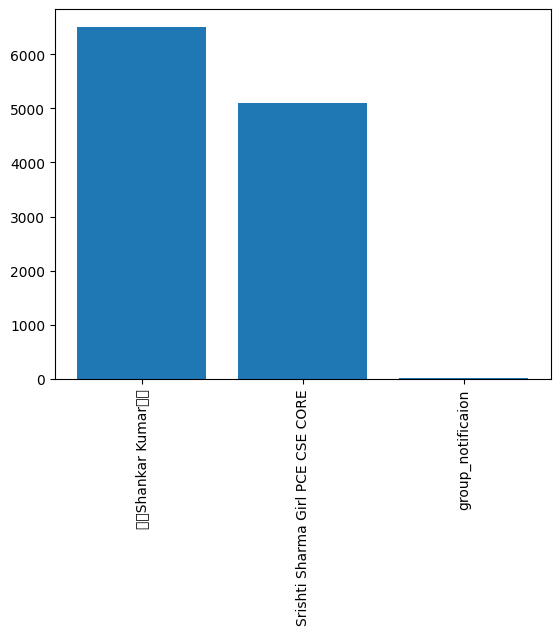

In [131]:
plt.bar(name,count)
plt.xticks(rotation='vertical')
plt.show()

In [132]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={'user':'name','count':'percent'})

,name,percent
0,🥳🥳Shankar Kumar🥳🥳,56.01
1,Srishti Sharma Girl PCE CSE CORE,43.92
2,group_notificaion,0.07


In [141]:
#remove group message
# remove media omitted message
# remive stop words

In [ ]:
temp=df[df['user']!='group_notification']
temp=temp[temp['message']!='<Media omitted>\n']
temp=temp[temp['message']!='edited>\n']


In [169]:
f=open("D:/FINAL_YEAR_PROJECTS/MACHINE_LEARNING_PROJECT/WHATSAPP_CHAT_ANALYZER/stop_hinglish.txt")
stop_words=f.read()
print(stop_words)

.
..
...
?
-
--
1
2
3
4
5
6
7
8
9
0
a
aadi
aaj
aap
aapne
aata
aati
aaya
aaye
ab
abbe
abbey
abe
abhi
able
about
above
accha
according
accordingly
acha
achcha
across
actually
after
afterwards
again
against
agar
ain
aint
ain't
aisa
aise
aisi
alag
all
allow
allows
almost
alone
along
already
also
although
always
am
among
amongst
an
and
andar
another
any
anybody
anyhow
anyone
anything
anyway
anyways
anywhere
ap
apan
apart
apna
apnaa
apne
apni
appear
are
aren
arent
aren't
around
arre
as
aside
ask
asking
at
aur
avum
aya
aye
baad
baar
bad
bahut
bana
banae
banai
banao
banaya
banaye
banayi
banda
bande
bandi
bane
bani
bas
bata
batao
bc
be
became
because
become
becomes
becoming
been
before
beforehand
behind
being
below
beside
besides
best
better
between
beyond
bhai
bheetar
bhi
bhitar
bht
bilkul
bohot
bol
bola
bole
boli
bolo
bolta
bolte
bolti
both
brief
bro
btw
but
by
came
can
cannot
cant
can't
cause
causes
certain
certainly
chahiye
chaiye
chal
chalega
chhaiye
clearly
c'mon
com
come
comes
could
coul

In [170]:
words=[]
for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)
    words.extend(message.split())


In [171]:
words

['messages',
 'calls',
 'end-to-end',
 'encrypted.',
 'chat',
 'read,',
 'listen',
 'to,',
 'share',
 'them.',
 'learn',
 'more.',
 'Messages',
 'and',
 'calls',
 'are',
 'end-to-end',
 'encrypted.',
 'Only',
 'people',
 'in',
 'this',
 'chat',
 'can',
 'read,',
 'listen',
 'to,',
 'or',
 'share',
 'them.',
 'Learn',
 'more.',
 '!!',
 'Hello',
 '!!',
 'math',
 'notes',
 'mujha',
 '!!',
 'Kal',
 'tum',
 'apna',
 'math',
 'notes',
 'mujha',
 'de',
 'sakti',
 'hu',
 '!!',
 'ok',
 'jara',
 'mefa',
 'padha',
 'duge',
 'topic',
 'dege',
 'mefa',
 'samaz',
 'class',
 'upper',
 'usko',
 'day',
 '!!',
 'Please',
 'jara',
 'se',
 'Mefa',
 'padha',
 'duge',
 'ya',
 'main',
 'main',
 'topic',
 'bata',
 'dege',
 'mujhe',
 'es',
 'baar',
 'MEFA',
 'ma',
 'kuch',
 'nahi',
 'samaz',
 'aya',
 'class',
 'ma',
 'upper',
 'exam',
 'bhe',
 'usko',
 '1',
 'day',
 'he',
 'ha',
 'please',
 '!!',
 'divedi',
 'guidance',
 'youtube',
 'channel',
 'jha',
 'sbhi',
 'chapter',
 'revision',
 'video',
 "hai'",
 'mujh

In [172]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,to,1424
1,hai,1346
2,ha,1326
3,ma,1324
4,ka,1312
5,message,1285
6,se,1079
7,kar,1042
8,edited>,884
9,me,843
